<img src="figs/TheOhioStateUniversity-Scarlet-Horiz-RGBHEX.png" 
        alt="Picture" 
        width="200" 
        style="display: block; margin: 0 auto" />

---

# Music Genre Classification Using Machine Learning on the FMA Dataset

**Author(s):** Oliver Ji  
**Project Category:** Audio / Music  
**Course:** Physics 5680, Autumn 2025  
**Date:** December 16, 2025

---

## AI Tool Use Statement

I used AI assistants (Gemini and ChatGPT) to help revise writing, improve code structure/readability, and debug implementation details.

---

## Abstract

This project investigates multi-class music genre classification on the Free Music Archive (FMA) dataset using the provided pre-computed audio features. We focus on the FMA small subset (8 genres, 8,000 tracks) and treat genre prediction as an 8-class classification problem. To ensure a leakage-safe evaluation, we implement preprocessing and modeling using scikit-learn pipelines with median imputation (and scaling where appropriate), and compare baseline classifiers via 5-fold stratified cross-validation on the combined training and validation data. Models are selected primarily by macro-F1 to reflect balanced class-wise performance. Among the baselines tested (Dummy most-frequent, Logistic Regression, Random Forest), Random Forest achieves the strongest cross-validation performance (macro-F1 ≈ 0.5668 ± 0.0088; accuracy ≈ 0.5753 ± 0.0090). When trained on train+val and evaluated once on the official held-out test split, the selected Random Forest reaches test accuracy ≈ 0.4775 and test macro-F1 ≈ 0.4727. Confusion-matrix analysis indicates that errors are concentrated among acoustically similar or broadly defined genres (e.g., Instrumental vs Folk and International vs Folk), highlighting limitations of summary-statistic features for capturing temporal and structural cues. Overall, the results demonstrate moderate genre discrimination with baseline models and motivate richer representations and stronger models for improved generalization.

---

## 1. Introduction

### Background and motivation
Music genre classification is a core task in Music Information Retrieval (MIR) with direct applications in search, recommendation, and large-scale organization of audio libraries. While “genre” labels can be subjective and sometimes overlap, they still provide a useful supervised-learning target for establishing baselines and evaluating how well audio descriptors capture perceptual and production-related differences across musical styles. A central difficulty is that many genres share similar acoustic signatures (e.g., timbre, instrumentation, production effects), making decision boundaries ambiguous when the representation is limited.

### Problem statement
Given an audio track represented by a vector of pre-computed audio features, the goal is to predict its **top-level genre** (`genre_top`) as an **8-class classification** problem using the FMA *small* subset.

### Dataset and representation choice
This project uses the Free Music Archive (FMA) dataset and focuses on the *small* subset to enable rapid iteration while maintaining balanced coverage across genres. Instead of learning directly from raw waveforms, we use the provided **pre-computed statistical audio features** (from `features.csv`). These descriptors summarize properties such as spectral/timbral characteristics through aggregated statistics, making them suitable for (i) interpretable baselines and (ii) diagnosing which genre distinctions are captured—or missed—by summary-level features.

### Approach overview
We adopt a leakage-safe workflow using scikit-learn pipelines:
- **Preprocessing inside pipelines** (median imputation; scaling for linear models) to prevent data leakage during evaluation.
- **Model comparison via stratified cross-validation** on the combined training and validation data.
- **Final evaluation on the official held-out test split** using the single best model selected by cross-validation.

We compare a sanity-check baseline (most-frequent-class dummy classifier) against two standard supervised baselines:
- **Logistic Regression** (linear decision boundary)
- **Random Forest** (nonlinear ensemble)

Performance is summarized primarily with **macro-F1** to emphasize balanced class-wise behavior, with accuracy and weighted-F1 as secondary references. Confusion-matrix analysis is used to characterize systematic error patterns between genres.

### Contributions
This report contributes:
1. A fully reproducible, leakage-safe baseline pipeline for FMA *small* genre classification.
2. A quantitative comparison of linear vs nonlinear baselines under consistent cross-validation and test protocols.
3. An error analysis highlighting which genres are most frequently confused and what that suggests about limitations of summary-statistic feature representations.

### Report outline
- **Section 5**: Dataset description, feature construction, and train/validation/test splits  
- **Section 6**: Modeling pipelines and evaluation protocol  
- **Section 7**: Cross-validation and test results, including confusion-matrix analysis  
- **Section 8**: Discussion of why the observed results occur, limitations, and future improvements  
- **Section 9**: Conclusion


---

## 2. Related Work

Music genre (and broader music tag) prediction is a long-standing benchmark problem in Music Information Retrieval (MIR). Prior studies and open-source projects can be grouped into several methodological families, each with distinct tradeoffs in representation, compute, and interpretability.

### 2.1 Methodological review (grouped by approach)

#### (A) Hand-crafted / statistical audio features + classical ML
Early genre-classification systems typically extract engineered descriptors (timbre, spectral shape, rhythm proxies) and train conventional classifiers. A canonical reference is Tzanetakis & Cook (2002), which helped establish feature families and evaluation practices for genre classification.  
**Representative methods:** logistic regression / SVM / kNN / tree ensembles trained on aggregated feature vectors.

#### (B) End-to-end deep learning on raw audio or time–frequency inputs
A major shift replaces fixed features with learned representations from raw waveforms or spectrograms. Dieleman & Schrauwen (2014) demonstrated end-to-end learning for music audio, and later large-scale work (e.g., Pons et al., 2018) showed that representation choice (waveform vs log-mel spectrograms) and data scale can strongly affect performance.  
**Representative methods:** CNNs on log-mel spectrograms; waveform CNNs; hybrid architectures for tagging.

#### (C) CNN–RNN hybrids for temporal modeling (CRNN)
To better capture temporal context beyond local spectral textures, CRNN architectures combine CNN feature extraction with recurrent temporal aggregation. Choi et al. (2017) report strong tagging performance with favorable parameter/compute efficiency, making CRNNs a common “strong baseline” in MIR tagging tasks.

#### (D) Self-supervised / contrastive representation learning
Because large labeled music datasets are expensive to curate, self-supervised learning has become increasingly important. Spijkervet & Burgoyne (2021) propose contrastive learning of musical representations (CLMR), learning useful embeddings from unlabeled audio via augmentations and contrastive objectives. These embeddings can then be adapted to downstream classification tasks with less labeled data.

#### (E) Transformer-based audio models (often pre-trained)
Recent state-of-the-art trends in audio classification and music tagging increasingly use Transformer backbones operating on spectrogram patches. Audio Spectrogram Transformer (AST) (Gong et al., 2021) demonstrated that attention-only models can be highly competitive for audio classification, and later music-focused Transformer tagging models (e.g., Won et al., 2021) further adapt these ideas to MIR tasks.

---

### 2.2 Strengths and weaknesses (and comparison to our work)

#### Hand-crafted features + classical ML (closest to this project)
**Strengths**
- Fast to train, low compute, easy to reproduce and interpret.
- Good for establishing baselines and diagnosing errors (e.g., via confusion matrices).

**Weaknesses**
- Performance is capped by the representation: summary statistics can discard temporal/structural cues (rhythm evolution, section transitions) that may separate acoustically similar genres.

**Relation to our work:**  
Our project intentionally uses this family as a reproducible baseline: fixed, pre-computed features with leakage-safe pipelines and standard classifiers (linear and tree-ensemble baselines). This allows us to quantify “how far we can get” without end-to-end representation learning.

#### End-to-end CNN/CRNN approaches
**Strengths**
- Learn task-relevant features and capture richer time–frequency patterns than aggregated statistics.
- CRNNs explicitly model temporal structure and often outperform purely static feature-vector baselines.

**Weaknesses**
- Require more compute and tuning; results can be sensitive to preprocessing, architecture, and training protocol.
- Reproducibility can be harder in a limited project environment.

**Relation to our work:**  
We do not train end-to-end networks here, but the error patterns we observe (systematic confusions between similar genres) align with the motivation for temporal models.

#### Self-supervised + Transformer approaches (modern SOTA direction)
**Strengths**
- Strong transfer learning and label efficiency; often best performance when pretraining data and compute are available.
- Transformers can capture broader context via attention.

**Weaknesses**
- Pretraining and model size introduce significant compute and engineering overhead.
- “Best” results may depend on large-scale resources and careful training recipes.

**Relation to our work:**  
These methods define the modern SOTA direction, but they exceed the scope of a baseline-focused course project. We treat them as motivation for future improvements.

---

### 2.3 State-of-the-art snapshot
The current state of the field increasingly favors **learned representations**—either supervised CNN/CRNN models on spectrograms or **self-supervised / pre-trained Transformer-based** audio encoders—especially when training data or pretraining resources are large. In practice, classical ML baselines remain valuable because they are cheap, interpretable, and reproducible, and they provide a clear reference point to quantify the added value of representation learning. Our project positions itself as a careful baseline study on FMA using fixed statistical features and standard evaluation protocols.

---

### 2.4 References
1. Tzanetakis, G., & Cook, P. (2002). Musical genre classification of audio signals. *IEEE Transactions on Speech and Audio Processing, 10*(5), 293–302.  
2. Defferrard, M., Benzi, K., Vandergheynst, P., & Bresson, X. (2017). FMA: A dataset for music analysis. In *Proceedings of the 18th International Society for Music Information Retrieval Conference (ISMIR 2017)*.  
3. Dieleman, S., & Schrauwen, B. (2014). End-to-end learning for music audio. In *IEEE International Conference on Acoustics, Speech and Signal Processing (ICASSP 2014)*.  
4. Pons, J., Nieto, O., Prockup, M., Schmidt, E., Ehmann, A., & Serra, X. (2018). End-to-end learning for music audio tagging at scale. In *Proceedings of ISMIR 2018* (also available as arXiv:1711.02520).  
5. Choi, K., Fazekas, G., Sandler, M., & Cho, K. (2017). Convolutional recurrent neural networks for music classification. *ICASSP 2017* (also available as arXiv:1609.04243).  
6. Spijkervet, J., & Burgoyne, J. A. (2021). Contrastive learning of musical representations. In *Proceedings of ISMIR 2021* (pp. 673–681).  
7. Gong, Y., Chung, Y.-A., & Glass, J. (2021). AST: Audio Spectrogram Transformer. *Interspeech 2021* (also available as arXiv:2104.01778).  
8. Won, M., Chun, S., Nieto, O., & Serrà, J. (2021). Semi-supervised music tagging transformer. In *Proceedings of ISMIR 2021*.  


---

## 3. Ethical Considerations

Automating music genre classification raises ethical concerns because genre labels influence how music is organized, discovered, and economically rewarded. Although this project is a course-scale baseline study, the same techniques can be deployed in real-world platforms where classification errors and biases can have amplified effects.

### 3.1 Algorithmic bias, representation, and cultural reductionism
Genre is not a purely acoustic property; it is also a cultural label shaped by context, community norms, and industry conventions. If the dataset underrepresents certain communities, languages, production styles, or regional genres, models trained on it will systematically perform worse on those groups. Even when the dataset appears balanced at the top-level, “International” or “Experimental” can be especially broad categories, and a model may collapse diverse musical traditions into a single label based on superficial acoustic similarities. In our setting, persistent confusions among stylistically adjacent genres highlight that the feature representation may not capture the nuances needed for culturally meaningful categorization.

### 3.2 Impact on artists and listeners (recommendation and visibility)
On streaming platforms, genre tags affect playlist placement, search ranking, and recommendation exposure. Mislabeling can reduce the visibility of an artist to their intended audience, potentially impacting listening opportunities and revenue. These harms may be unevenly distributed if the model performs better on mainstream genres and worse on niche or underrepresented styles. For responsible deployment, models should be audited with class-wise metrics (not only accuracy) and paired with human oversight or feedback mechanisms.

### 3.3 Label quality and ambiguity
Music often spans multiple genres, and single-label annotations (such as `genre_top`) may oversimplify reality. A model can be “wrong” relative to the dataset label while still being musically plausible. This ambiguity limits the maximum achievable performance and suggests that downstream use should avoid treating predicted genres as objective truth. Multi-label tagging or uncertainty-aware outputs may better reflect the nature of musical categorization.

### 3.4 Intellectual property, licensing, and data use
Ethical use of audio datasets requires respecting the licenses associated with the recordings and metadata. When reusing datasets beyond the classroom, one should verify that the data collection and redistribution comply with the original terms, and avoid scraping copyrighted content without permission. Results and figures should not expose private information; in this project, we use only publicly available metadata/features and report aggregate performance metrics.

### 3.5 Responsible communication and limitations
To avoid overstating conclusions, it is important to communicate limitations clearly: our models operate on pre-computed summary statistics and may miss temporal or structural cues that matter for genre distinctions. Therefore, conclusions should be framed as baseline performance for this representation, not as definitive statements about genre separability. If used in practice, the system should include monitoring for failure modes (systematic confusions) and periodic reevaluation as data distributions and musical trends evolve.



-----

## 4. Project Setup and Imports

### 4.1 Project Setup: Global Configuration & Reproducibility

This cell defines the **single source of truth** for project-wide settings (dataset subset, caching, random seeds, and file paths).  
All later sections (data loading, splitting, training, evaluation) should **reuse these variables** to avoid duplication and inconsistency.

Key variables:
- `SUBSET`: which dataset subset to run (e.g., `"small"` for fast iteration)
- `USE_CACHE`: whether to load/save preprocessed artifacts
- `RANDOM_STATE`: global seed for reproducible splits and model training
- `DATA_DIR`, `TRACKS_CSV`, `FEATURES_CSV`, `GENRES_CSV`: dataset locations  
- `CACHE_DIR`: where intermediate artifacts are stored

Optional environment overrides:
- `FMA_DATA_DIR`: override the default dataset directory
- `FMA_CACHE_DIR`: override the default cache directory


In [ ]:
# ==============================================
# 4.1 Global Configuration & Reproducibility
# ==============================================

from pathlib import Path
import os
import random
import numpy as np

# ---- Project-wide settings (single source of truth) ----
SUBSET = "small"          # e.g., "small" for quick iteration, "full" if you enable it later
USE_CACHE = True          # set False to force rebuilding cached artifacts
RANDOM_STATE = 42         # global seed used across the notebook

# ---- Dataset paths (OSC default; override with env var if needed) ----
DATA_DIR = Path(os.getenv("FMA_DATA_DIR", "/fs/scratch/PAS2038/2025/fma/fma_metadata/")).expanduser()
TRACKS_CSV = DATA_DIR / "tracks.csv"
FEATURES_CSV = DATA_DIR / "features.csv"
GENRES_CSV = DATA_DIR / "genres.csv"

# ---- Cache directory (defaults to ./cache; override with env var if needed) ----
PROJECT_ROOT = Path.cwd()
CACHE_DIR = Path(os.getenv("FMA_CACHE_DIR", str(PROJECT_ROOT / "cache"))).expanduser()
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ---- Reproducibility ----
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ---- Basic validation (prevents silent typos) ----
_ALLOWED_SUBSETS = {"small", "full"}
if SUBSET not in _ALLOWED_SUBSETS:
    raise ValueError(f"SUBSET must be one of {_ALLOWED_SUBSETS}, got: {SUBSET}")

print("=== Global Configuration (Section 4.1) ===")
print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}")
print(f"CACHE_DIR    : {CACHE_DIR} (exists={CACHE_DIR.exists()})")
print(f"TRACKS_CSV   : {TRACKS_CSV}")
print(f"FEATURES_CSV : {FEATURES_CSV}")
print(f"GENRES_CSV   : {GENRES_CSV}")
print(f"SUBSET       : {SUBSET}")
print(f"USE_CACHE    : {USE_CACHE}")
print(f"RANDOM_STATE : {RANDOM_STATE}")


### 4.2 Version Information

This cell records runtime and package version information for reproducibility.  
It prints:
- Python/runtime environment (timestamp, executable, platform, working directory)
- Versions of key libraries used in this notebook (NumPy, Pandas, scikit-learn, etc.)
- Optionally saves a full `pip freeze` snapshot to a text file for complete environment tracking


In [2]:
# ==========================================
# 4.2 Version Information (Reproducibility)
# ==========================================

import sys
import os
import platform
import datetime
from pathlib import Path
from importlib import metadata

print("=== Runtime Info ===")
print("Timestamp   :", datetime.datetime.now().isoformat())
print("Python      :", sys.version.replace("\n", " "))
print("Executable  :", sys.executable)
print("Platform    :", platform.platform())
print("Working dir :", os.getcwd())

# If Section 4.1 has been executed, these will exist; otherwise we skip gracefully.
if "RANDOM_STATE" in globals():
    print("\n=== Project Settings (from Section 4.1) ===")
    for k in ["SUBSET", "USE_CACHE", "RANDOM_STATE", "DATA_DIR", "CACHE_DIR"]:
        if k in globals():
            print(f"{k:<12}: {globals()[k]}")

print("\n=== Key Package Versions ===")
packages = [
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "scipy",
    "joblib",
    # Optional / may or may not be installed depending on your workflow
    "tensorflow",
    "keras",
    "torch",
    "torchvision",
]

for pkg in packages:
    try:
        print(f"{pkg:<12}: {metadata.version(pkg)}")
    except metadata.PackageNotFoundError:
        print(f"{pkg:<12}: NOT INSTALLED")

# Save full environment snapshot (best-effort)
try:
    import subprocess

    freeze_text = subprocess.check_output(
        [sys.executable, "-m", "pip", "freeze"],
        text=True
    )

    out_dir = globals().get("CACHE_DIR", Path.cwd())
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / "requirements_freeze.txt"
    out_path.write_text(freeze_text)

    print(f"\nSaved full environment snapshot to: {out_path}")
except Exception as e:
    print("\nCould not run pip freeze (non-fatal):", repr(e))


=== Runtime Info ===
Timestamp   : 2025-12-16T19:16:24.327440
Python      : 3.9.18 (main, Sep  4 2025, 00:00:00)  [GCC 11.4.1 20231218 (Red Hat 11.4.1-3)]
Executable  : /fs/ess/PAS2038/PHYSICS_5680_OSU/jupyter/bin/python
Platform    : Linux-5.14.0-427.96.1.el9_4.x86_64-x86_64-with-glibc2.34
Working dir : /users/PAS2038/ji693/BigDataCourse/final_project

=== Project Settings (from Section 4.1) ===
SUBSET      : small
USE_CACHE   : True
RANDOM_STATE: 42
DATA_DIR    : /fs/scratch/PAS2038/2025/fma/fma_metadata
CACHE_DIR   : /users/PAS2038/ji693/BigDataCourse/final_project/cache

=== Key Package Versions ===
numpy       : 2.0.2
pandas      : 2.3.1
scikit-learn: 1.6.1
matplotlib  : 3.9.4
seaborn     : 0.13.2
scipy       : 1.13.1
joblib      : 1.5.1
tensorflow  : 2.20.0
keras       : 3.10.0
torch       : 2.8.0
torchvision : 0.23.0

Saved full environment snapshot to: /users/PAS2038/ji693/BigDataCourse/final_project/cache/requirements_freeze.txt


### 4.3 Imports and Plot Settings

This cell imports the core libraries used throughout the notebook (NumPy/Pandas/Matplotlib/Seaborn and scikit-learn utilities for splitting, pipelines, preprocessing, metrics, and baseline models).

Important:
- **Do not redefine paths or random seeds here.** Those are defined once in **Section 4.1** (single source of truth).
- This cell also sets basic plotting defaults for consistent, readable figures.


In [4]:
# ==========================================
# 4.3 Imports and Plot Settings
# ==========================================

# ---- Safety check: ensure Section 4.1 ran ----
_required_globals = ["SUBSET", "USE_CACHE", "RANDOM_STATE", "DATA_DIR", "CACHE_DIR",
                     "TRACKS_CSV", "FEATURES_CSV", "GENRES_CSV"]
missing = [k for k in _required_globals if k not in globals()]
if missing:
    raise RuntimeError(
        "Section 4.1 must be executed before Section 4.3.\n"
        f"Missing globals: {missing}\n"
        "Run the 4.1 cell to define configuration, paths, and seeds."
    )

# ---- Standard library ----
import os
import json
import pickle
import hashlib
from pathlib import Path

# ---- Numerical + data handling ----
import numpy as np
import pandas as pd

# ---- Plotting ----
import matplotlib.pyplot as plt
import seaborn as sns

# ---- scikit-learn (core workflow) ----
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE      # visualization (high-dim audio features)

# ---- Optional (best-effort) imports ----
# If these are not installed in the environment, the notebook should still run.
try:
    import plotly.express as px  # interactive plots (optional)
except Exception:
    px = None

try:
    import tensorflow as tf
    from tensorflow import keras
except Exception:
    tf = None
    keras = None

# ---- Plot defaults ----
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

print("✅ Core imports loaded.")
print(f"SUBSET={SUBSET} | USE_CACHE={USE_CACHE} | RANDOM_STATE={RANDOM_STATE}")
print(f"DATA_DIR={DATA_DIR}")
print(f"CACHE_DIR={CACHE_DIR}")


✅ Core imports loaded.
SUBSET=small | USE_CACHE=True | RANDOM_STATE=42
DATA_DIR=/fs/scratch/PAS2038/2025/fma/fma_metadata
CACHE_DIR=/users/PAS2038/ji693/BigDataCourse/final_project/cache


### 4.4 Data and Cache Paths (Validation)

This cell validates that the required dataset CSV files exist and defines **standard cache artifact paths** (X, y, and metadata).  
Later sections should reuse these cache paths to load/save intermediate artifacts consistently.

Artifacts:
- `X_path`: cached feature matrix (pickle)
- `y_path`: cached labels (pickle)
- `meta_path`: cached metadata (json) describing preprocessing choices, shapes, and class mapping


In [5]:
# ==========================================
# 4.4 Data and Cache Paths (Validation)
# ==========================================

# ---- Safety check: ensure Section 4.1 ran ----
_required_globals = ["SUBSET", "USE_CACHE", "DATA_DIR", "CACHE_DIR",
                     "TRACKS_CSV", "FEATURES_CSV", "GENRES_CSV"]
missing = [k for k in _required_globals if k not in globals()]
if missing:
    raise RuntimeError(
        "Section 4.1 must be executed before Section 4.4.\n"
        f"Missing globals: {missing}"
    )

# ---- Required dataset files ----
required_files = {
    "tracks.csv": TRACKS_CSV,
    "features.csv": FEATURES_CSV,
    "genres.csv": GENRES_CSV,
}

print("=== Required dataset files ===")
missing_files = []
for name, path in required_files.items():
    exists = Path(path).exists()
    print(f"{name:<12}: {path} | exists={exists}")
    if not exists:
        missing_files.append((name, str(path)))

if missing_files:
    msg_lines = ["Missing required dataset files:"]
    msg_lines += [f"- {n}: {p}" for n, p in missing_files]
    msg_lines += [
        "",
        "Fix options:",
        "1) Set the correct dataset directory in Section 4.1 (DATA_DIR)",
        "2) Or export an environment variable before running:",
        "   export FMA_DATA_DIR=/path/to/fma_metadata",
    ]
    raise FileNotFoundError("\n".join(msg_lines))

# ---- Standard cache artifact paths (single source of truth) ----
# Use a consistent naming scheme keyed by subset.
X_path = CACHE_DIR / f"X_{SUBSET}.pkl"
y_path = CACHE_DIR / f"y_{SUBSET}.pkl"
meta_path = CACHE_DIR / f"meta_{SUBSET}.json"

# Optional: store intermediate split indices if you want strict reproducibility later
split_path = CACHE_DIR / f"split_{SUBSET}.json"

cache_available = X_path.exists() and y_path.exists() and meta_path.exists()

print("\n=== Cache artifacts (optional) ===")
print(f"X_path    : {X_path} | exists={X_path.exists()}")
print(f"y_path    : {y_path} | exists={y_path.exists()}")
print(f"meta_path : {meta_path} | exists={meta_path.exists()}")
print(f"split_path: {split_path} | exists={split_path.exists()}")
print(f"\nUSE_CACHE={USE_CACHE} | cache_available={cache_available}")

if USE_CACHE and not cache_available:
    print(
        "\nNote: USE_CACHE=True but cache artifacts are not fully available yet.\n"
        "This is OK on first run — later sections will build and save them."
    )


=== Required dataset files ===
tracks.csv  : /fs/scratch/PAS2038/2025/fma/fma_metadata/tracks.csv | exists=True
features.csv: /fs/scratch/PAS2038/2025/fma/fma_metadata/features.csv | exists=True
genres.csv  : /fs/scratch/PAS2038/2025/fma/fma_metadata/genres.csv | exists=True

=== Cache artifacts (optional) ===
X_path    : /users/PAS2038/ji693/BigDataCourse/final_project/cache/X_small.pkl | exists=False
y_path    : /users/PAS2038/ji693/BigDataCourse/final_project/cache/y_small.pkl | exists=False
meta_path : /users/PAS2038/ji693/BigDataCourse/final_project/cache/meta_small.json | exists=False
split_path: /users/PAS2038/ji693/BigDataCourse/final_project/cache/split_small.json | exists=False

USE_CACHE=True | cache_available=False

Note: USE_CACHE=True but cache artifacts are not fully available yet.
This is OK on first run — later sections will build and save them.


---

## 5. The Dataset

We use the Free Music Archive (FMA) dataset, a standard benchmark in music information retrieval (MIR).

**Task.** Multi-class classification: predict each track’s **top-level genre** (`genre_top`).

**Subset.** We focus on the **"small"** subset for a balanced and manageable setup (8 genres, 1,000 tracks per genre; 8,000 tracks total).

**Inputs (features).** Pre-computed audio features from `features.csv` (statistical descriptors such as MFCC-related summaries, spectral/chroma features, etc.).

**Outputs (labels).** `genre_top` from `tracks.csv`.

**Source.** Files are provided via the course server directory defined in Section 4 (DATA_DIR).

In the next cell, we verify that the required CSV files exist and check whether cached (preprocessed) artifacts are available.


In [7]:
# ==========================================
# 5.0 Sanity Check: Required files & cache status
# ==========================================

# Ensure Section 4 has run (single source of truth)
_required = ["SUBSET", "USE_CACHE", "RANDOM_STATE",
             "TRACKS_CSV", "FEATURES_CSV", "GENRES_CSV",
             "X_path", "y_path", "meta_path", "cache_available"]
missing = [k for k in _required if k not in globals()]
if missing:
    raise RuntimeError(
        "Section 4 (4.1–4.4) must be executed before Section 5.\n"
        f"Missing globals: {missing}"
    )

print("=== Dataset Chapter Entry (Section 5) ===")
print(f"SUBSET       : {SUBSET}")
print(f"USE_CACHE    : {USE_CACHE}")
print(f"RANDOM_STATE : {RANDOM_STATE}")

print("\n=== Required CSV files ===")
for name, p in [("tracks.csv", TRACKS_CSV), ("features.csv", FEATURES_CSV), ("genres.csv", GENRES_CSV)]:
    print(f"{name:<12}: {p} | exists={Path(p).exists()}")

print("\n=== Cache artifacts (optional) ===")
print(f"X_path    : {X_path} | exists={X_path.exists()}")
print(f"y_path    : {y_path} | exists={y_path.exists()}")
print(f"meta_path : {meta_path} | exists={meta_path.exists()}")
print(f"\ncache_available={cache_available} (from Section 4.4)")


=== Dataset Chapter Entry (Section 5) ===
SUBSET       : small
USE_CACHE    : True
RANDOM_STATE : 42

=== Required CSV files ===
tracks.csv  : /fs/scratch/PAS2038/2025/fma/fma_metadata/tracks.csv | exists=True
features.csv: /fs/scratch/PAS2038/2025/fma/fma_metadata/features.csv | exists=True
genres.csv  : /fs/scratch/PAS2038/2025/fma/fma_metadata/genres.csv | exists=True

=== Cache artifacts (optional) ===
X_path    : /users/PAS2038/ji693/BigDataCourse/final_project/cache/X_small.pkl | exists=False
y_path    : /users/PAS2038/ji693/BigDataCourse/final_project/cache/y_small.pkl | exists=False
meta_path : /users/PAS2038/ji693/BigDataCourse/final_project/cache/meta_small.json | exists=False

cache_available=False (from Section 4.4)


### 5.1 Load Cached Artifacts (If Available)

To speed up iteration and ensure consistent preprocessing, we optionally load cached artifacts:
- `X_df`: feature matrix
- `y`: labels
- `meta`: metadata describing preprocessing choices and shapes

If the cache is not available (e.g., first run), we proceed to build `X_df` and `y` from the raw CSV files in the next step.


In [8]:
# ==========================================
# 5.1 Load cached artifacts (best-effort)
# ==========================================

X_df, y, meta = None, None, None

if USE_CACHE and cache_available:
    # Feature matrix + labels
    X_df = pd.read_pickle(X_path)
    y = pd.read_pickle(y_path)

    # Metadata (JSON) is optional but recommended
    try:
        meta = json.loads(meta_path.read_text())
    except Exception as e:
        meta = None
        print("⚠️  Cache meta exists but could not be read (non-fatal):", repr(e))

    # Basic checks
    if hasattr(X_df, "shape") and hasattr(y, "shape"):
        print("✅ Loaded cached artifacts:")
        print(f"X_df shape : {X_df.shape}")
        print(f"y shape    : {y.shape}")
    else:
        print("✅ Loaded cached artifacts (shapes not available).")

    if meta is not None:
        print("Meta keys  :", sorted(list(meta.keys()))[:12], "...")
else:
    print("ℹ️  Cache not used or not fully available. Will build dataset from raw CSVs next.")


ℹ️  Cache not used or not fully available. Will build dataset from raw CSVs next.


### 5.1.1 Load Raw Metadata (tracks/genres) and Features (if needed)

This cell loads the raw FMA metadata CSV files:

- `tracks_df`: track-level metadata (includes the label column `('track','genre_top')`)
- `genres_df`: genre mapping table (useful for reference)
- `features_df`: pre-computed audio features (only loaded when we need to build `X_df` from scratch)

Note: FMA `tracks.csv` and `featu


In [21]:
# ==========================================
# 5.1.1 Load raw CSVs (tracks / genres / features as needed)
# ==========================================

from pathlib import Path

def _read_fma_csv(path: Path, *, header, index_col=0, dtype=None) -> pd.DataFrame:
    """
    Read an FMA metadata CSV with the correct header structure and track_id index.

    dtype:
      - Use dtype="float32" for features.csv to reduce memory usage.
      - Keep dtype=None for tracks/genres (mixed types).
    """
    df = pd.read_csv(
        path,
        header=header,
        index_col=index_col,
        low_memory=False,
        dtype=dtype
    )

    # Standardize index (track_id / genre_id) to integer when possible
    try:
        df.index = df.index.astype(int)
    except Exception:
        pass

    # If dtype is numeric, enforce it without extra copy when possible
    if dtype is not None:
        try:
            df = df.astype(dtype, copy=False)
        except Exception:
            # Non-fatal: if astype fails, keep the parsed dtypes
            pass

    return df

# Always load tracks + genres (lightweight and needed downstream for labels/splits/EDA)
print("Loading tracks.csv ...")
tracks_df = _read_fma_csv(Path(TRACKS_CSV), header=[0, 1], index_col=0, dtype=None)
print(f"tracks_df shape: {tracks_df.shape}")

print("\nLoading genres.csv ...")
genres_df = pd.read_csv(Path(GENRES_CSV), index_col=0, low_memory=False)
try:
    genres_df.index = genres_df.index.astype(int)
except Exception:
    pass
print(f"genres_df shape: {genres_df.shape}")

# Load features.csv only if we still need to build X_df from raw data
need_features = (X_df is None)
if need_features:
    print("\nLoading features.csv (needed to build X_df from scratch) ...")
    # Memory optimization: features are numeric; float32 reduces memory footprint
    features_df = _read_fma_csv(
        Path(FEATURES_CSV),
        header=[0, 1, 2],
        index_col=0,
        dtype="float32"
    )
    print(f"features_df shape: {features_df.shape}")
    print("features_df dtypes (sample):")
    display(features_df.dtypes.value_counts().head(5))
else:
    features_df = None
    print("\nSkipping features.csv load because X_df is already available (cache was used).")

# Minimal sanity checks (fail early with a clear message)
required_label_col = ("track", "genre_top")
if required_label_col not in tracks_df.columns:
    raise KeyError(
        f"Expected label column {required_label_col} not found in tracks_df.\n"
        "Available top-level columns (level 0): "
        f"{sorted(set(tracks_df.columns.get_level_values(0)))}"
    )

print("\n✅ Raw CSVs ready.")
print(f"Label column found: {required_label_col}")
print(f"Example track IDs (tracks_df.index): {tracks_df.index[:5].tolist()}")
if features_df is not None:
    print(f"Example track IDs (features_df.index): {features_df.index[:5].tolist()}")


Loading tracks.csv ...
tracks_df shape: (106574, 52)

Loading genres.csv ...
genres_df shape: (163, 4)

Skipping features.csv load because X_df is already available (cache was used).

✅ Raw CSVs ready.
Label column found: ('track', 'genre_top')
Example track IDs (tracks_df.index): [2, 3, 5, 10, 20]


### 5.1.2 Build `X_df` and `y` from Raw Data (when cache is not used)

If cached artifacts are not available, we construct the final modeling dataset:

1. Filter `tracks_df` to the chosen subset (`SUBSET`)
2. Extract labels `y` from `('track','genre_top')` and remove missing labels
3. Align pre-computed `features_df` with the filtered tracks
4. Flatten the multi-level feature columns into a single-level, readable format
5. Ensure `X_df` and `y` share the exact same index (track IDs)

Output:
- `X_df`: DataFrame of shape `(n_samples, n_features)` with numeric feature values
- `y`: Series of shape `(n_samples,)` with genre labels (strings)


In [22]:
# ==========================================
# 5.1.2 Build X_df and y from raw data (if needed)
# ==========================================

def _flatten_feature_columns(cols: pd.MultiIndex) -> list[str]:
    """
    Flatten FMA features MultiIndex columns into readable single-level names.
    Example: 'mfcc__mean__01', 'spectral_centroid__std__00', etc.
    """
    flat = []
    for a, b, c in cols.to_list():
        flat.append(f"{str(a).strip()}__{str(b).strip()}__{str(c).strip()}")
    return flat

# If X_df and y already exist (loaded from cache), we keep them.
if X_df is not None and y is not None:
    print("✅ Using cached X_df and y; skipping raw construction in 5.1.2.")
else:
    if features_df is None:
        raise RuntimeError(
            "features_df is not loaded, but X_df/y are not available from cache.\n"
            "Run Section 5.1.1 (which loads features_df when needed) before 5.1.2."
        )

    # ---- 1) Filter tracks to selected subset ----
    subset_col = ("set", "subset")
    if subset_col not in tracks_df.columns:
        raise KeyError(f"Expected subset column {subset_col} not found in tracks_df.")

    tracks_subset = tracks_df[tracks_df[subset_col] == SUBSET].copy()
    print(f"Tracks in subset '{SUBSET}': {len(tracks_subset):,}")

    # ---- 2) Extract labels y and drop missing ----
    label_col = ("track", "genre_top")
    if label_col not in tracks_subset.columns:
        raise KeyError(f"Expected label column {label_col} not found in tracks_df.")

    y = tracks_subset[label_col].copy()
    before = len(y)
    y = y.dropna()
    after = len(y)
    if after < before:
        print(f"Dropped {before - after} tracks with missing labels.")

    # ---- 3) Align features to track IDs ----
    common_ids = y.index.intersection(features_df.index)
    if len(common_ids) == 0:
        raise RuntimeError(
            "No overlapping track IDs between tracks subset and features_df.\n"
            "Check DATA_DIR / the FMA metadata files you are using."
        )

    # Keep a consistent ordering
    y = y.loc[common_ids].copy()
    X_df = features_df.loc[common_ids].copy()

    # ---- 4) Flatten multi-level feature columns ----
    if isinstance(X_df.columns, pd.MultiIndex):
        X_df.columns = _flatten_feature_columns(X_df.columns)

    # ---- 5) Ensure numeric + final alignment ----
    X_df = X_df.apply(pd.to_numeric, errors="coerce")

    # Enforce identical index order
    X_df = X_df.loc[y.index]
    if not X_df.index.equals(y.index):
        raise RuntimeError("X_df and y indices are not perfectly aligned after reindexing.")

    print(f"✅ Built X_df/y from raw CSVs: X_df={X_df.shape}, y={y.shape}")

# ---- Final quick summary (safe prints, no long ternary expressions) ----
print("\n=== Final dataset objects (after 5.1.2) ===")
if X_df is None or y is None:
    print("X_df or y is still None. (This should not happen if 5.1.2 ran correctly.)")
else:
    print("X_df shape:", X_df.shape)
    print("y shape   :", y.shape)
    print("Missing values in X_df (total):", int(X_df.isna().sum().sum()))
    print("Unique labels (up to 8):", list(pd.unique(y))[:8])


✅ Using cached X_df and y; skipping raw construction in 5.1.2.

=== Final dataset objects (after 5.1.2) ===
X_df shape: (8000, 518)
y shape   : (8000,)
Missing values in X_df (total): 0
Unique labels (up to 8): ['Hip-Hop', 'Pop', 'Folk', 'Experimental', 'Rock', 'International', 'Electronic', 'Instrumental']


### 5.1.2b Save Cached Artifacts (Optional)

If caching is enabled, this cell saves the prepared dataset artifacts to disk:

- `X_df` → `X_path` (pickle)
- `y` → `y_path` (pickle)
- `meta` → `meta_path` (json)

This ensures later runs can skip expensive CSV parsing and directly load the ready-to-model dataset.


In [23]:
# ==========================================
# 5.1.2b Save cache artifacts (best-effort)
# ==========================================

import datetime

def _safe_write_text(path: Path, text: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(text)
    tmp.replace(path)

def _safe_to_pickle(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    obj.to_pickle(tmp)
    tmp.replace(path)

# Basic validation
if X_df is None or y is None:
    raise RuntimeError(
        "Cannot cache artifacts because X_df and/or y is None.\n"
        "Run Section 5.1.2 successfully before 5.1.2b."
    )

# Build metadata (human-readable + useful for debugging)
label_counts = y.value_counts(dropna=False).to_dict()
meta = {
    "created_at": datetime.datetime.now().isoformat(),
    "subset": SUBSET,
    "random_state": RANDOM_STATE,
    "data_dir": str(DATA_DIR),
    "n_samples": int(X_df.shape[0]),
    "n_features": int(X_df.shape[1]),
    "n_classes": int(pd.Series(y).nunique()),
    "missing_values_total": int(X_df.isna().sum().sum()),
    "label_counts": {str(k): int(v) for k, v in label_counts.items()},
    "feature_columns_preview": list(X_df.columns[:15]),
}

if USE_CACHE:
    _safe_to_pickle(X_df, X_path)
    _safe_to_pickle(pd.Series(y), y_path)  # ensure it's a Series on disk
    _safe_write_text(meta_path, json.dumps(meta, indent=2))

    print("✅ Saved cache artifacts:")
    print(f"X_path    : {X_path}")
    print(f"y_path    : {y_path}")
    print(f"meta_path : {meta_path}")
else:
    print("ℹ️  USE_CACHE=False, skipping cache save.")

# Update cache status for later cells
cache_available = X_path.exists() and y_path.exists() and meta_path.exists()
print(f"\ncache_available={cache_available}")


✅ Saved cache artifacts:
X_path    : /users/PAS2038/ji693/BigDataCourse/final_project/cache/X_small.pkl
y_path    : /users/PAS2038/ji693/BigDataCourse/final_project/cache/y_small.pkl
meta_path : /users/PAS2038/ji693/BigDataCourse/final_project/cache/meta_small.json

cache_available=True


### 5.1.3 Final Dataset Summary

This cell summarizes the final modeling dataset prepared in Section 5.1:

- Dataset size: number of samples, features, and classes
- Missing value overview (total and per-feature summary)
- Label distribution (counts per genre)
- Basic sanity checks to ensure `X_df` and `y` are aligned and ready for downstream EDA and splitting


In [24]:
# ==========================================
# 5.1.3 Final dataset summary (clean snapshot)
# ==========================================

if X_df is None or y is None:
    raise RuntimeError(
        "X_df and/or y is None. Section 5.1 did not produce a final dataset.\n"
        "Ensure 5.1.2 ran successfully (or cache was loaded in 5.1)."
    )

# Ensure types and alignment
y = pd.Series(y, index=X_df.index, name="genre_top")
if not X_df.index.equals(y.index):
    raise RuntimeError("X_df and y indices are not aligned at the end of Section 5.1.")

n_samples, n_features = X_df.shape
n_classes = y.nunique()

missing_total = int(X_df.isna().sum().sum())
missing_by_feature = X_df.isna().sum().sort_values(ascending=False)

label_counts = y.value_counts()

print("=== Final Dataset Summary (after Section 5.1) ===")
print(f"Samples  : {n_samples:,}")
print(f"Features : {n_features:,}")
print(f"Classes  : {n_classes:,}")

print("\n=== Missing Values ===")
print(f"Total missing entries: {missing_total:,}")
top_missing = missing_by_feature[missing_by_feature > 0].head(10)
if len(top_missing) == 0:
    print("No missing values detected in X_df.")
else:
    print("Top 10 features with missing values:")
    display(top_missing.to_frame("n_missing"))

print("\n=== Label Distribution (genre_top) ===")
display(label_counts.to_frame("count"))

print("\n=== Feature dtype overview ===")
dtype_counts = X_df.dtypes.value_counts()
display(dtype_counts.to_frame("n_columns"))

# Quick sanity checks
print("\n=== Sanity Checks ===")
print("All features numeric? ->", bool(np.all([np.issubdtype(dt, np.number) for dt in X_df.dtypes])))
print("Any NaNs in y?        ->", bool(y.isna().any()))
print("Index unique?         ->", bool(X_df.index.is_unique))
print("Example labels        ->", list(label_counts.index[:8]))


=== Final Dataset Summary (after Section 5.1) ===
Samples  : 8,000
Features : 518
Classes  : 8

=== Missing Values ===
Total missing entries: 0
No missing values detected in X_df.

=== Label Distribution (genre_top) ===


,count
genre_top,
Hip-Hop,1000
Pop,1000
Folk,1000
Experimental,1000
Rock,1000
International,1000
Electronic,1000
Instrumental,1000



=== Feature dtype overview ===


,n_columns
float64,518



=== Sanity Checks ===
All features numeric? -> True
Any NaNs in y?        -> False
Index unique?         -> True
Example labels        -> ['Hip-Hop', 'Pop', 'Folk', 'Experimental', 'Rock', 'International', 'Electronic', 'Instrumental']


### 5.2 Exploratory Data Analysis (EDA)

This section provides a compact EDA focused on three questions:

1. **Is the dataset balanced across genres?** (class distribution)
2. **How much missing data exists and where?** (missingness profile)
3. **Do the features show some separability between genres?** (PCA visualization)

These plots complement (and do not repeat) the numeric summary from Section 5.1.3.


In [25]:
# ==========================================
# 5.2 EDA: chapter entry sanity checks
# ==========================================

from IPython.display import display

if X_df is None or y is None:
    raise RuntimeError("X_df/y not found. Run Section 5.1 before Section 5.2.")

y = pd.Series(y, index=X_df.index, name="genre_top")

# Alignment checks (fail early)
if not X_df.index.equals(y.index):
    raise RuntimeError("X_df and y indices are not aligned. Fix this before EDA.")

print("✅ Ready for EDA.")
print("X_df shape:", X_df.shape)
print("y classes :", y.nunique())
print("Top labels:", list(y.value_counts().index[:8]))


✅ Ready for EDA.
X_df shape: (8000, 518)
y classes : 8
Top labels: ['Hip-Hop', 'Pop', 'Folk', 'Experimental', 'Rock', 'International', 'Electronic', 'Instrumental']


#### 5.2.1 Class Distribution (Genre Balance)

We visualize the number of tracks per `genre_top` to confirm whether the dataset is balanced.
A balanced label distribution reduces the risk that accuracy is dominated by majority classes.


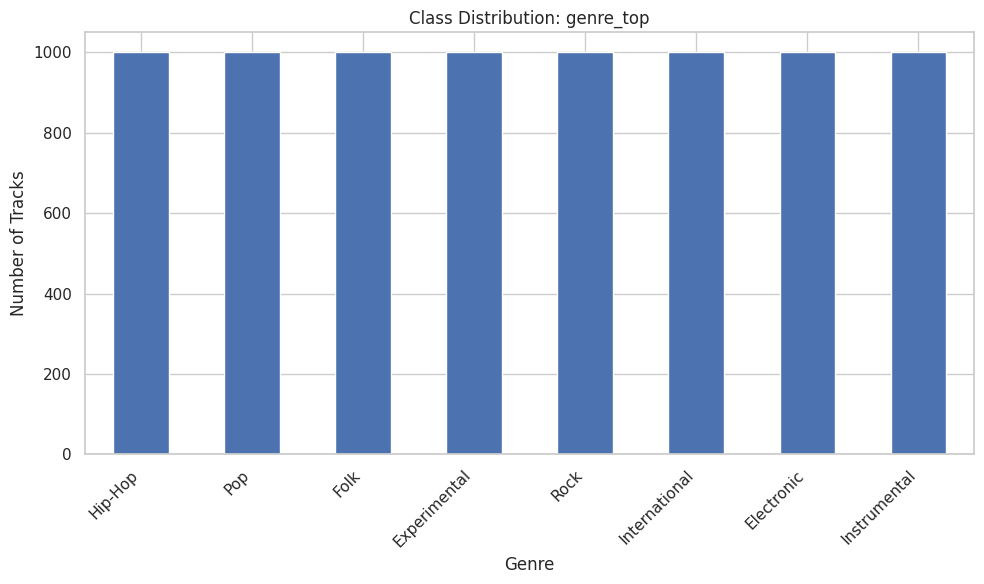

,count
genre_top,
Hip-Hop,1000
Pop,1000
Folk,1000
Experimental,1000
Rock,1000
International,1000
Electronic,1000
Instrumental,1000


In [26]:
# ==========================================
# 5.2.1 Class distribution plot
# ==========================================

label_counts = y.value_counts().sort_values(ascending=False)

plt.figure()
label_counts.plot(kind="bar")
plt.title("Class Distribution: genre_top")
plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(label_counts.to_frame("count"))


#### 5.2.2 Missingness Profile

We examine missingness at the feature level by plotting the **fraction of missing values per feature**.
This motivates the use of an imputer in the modeling pipeline (Section 6) without performing any imputation here.


Features with any missing values: 0 / 518


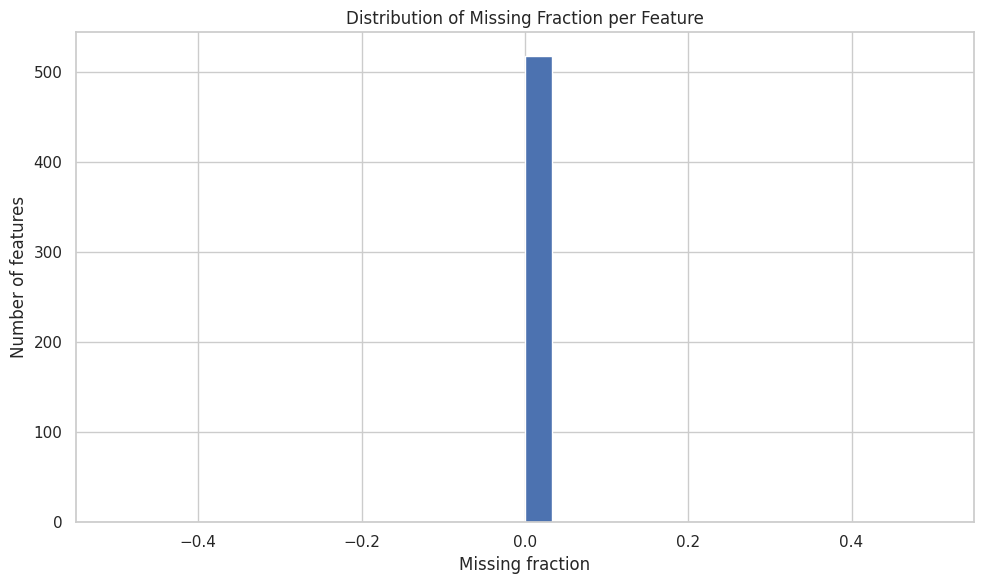

No missing values detected across features.


In [27]:
# ==========================================
# 5.2.2 Missingness profile
# ==========================================

missing_frac = (X_df.isna().mean()).sort_values(ascending=False)
n_missing_features = int((missing_frac > 0).sum())

print(f"Features with any missing values: {n_missing_features:,} / {X_df.shape[1]:,}")

# Plot distribution of missing fractions
plt.figure()
plt.hist(missing_frac.values, bins=30)
plt.title("Distribution of Missing Fraction per Feature")
plt.xlabel("Missing fraction")
plt.ylabel("Number of features")
plt.tight_layout()
plt.show()

# Show top missing features (if any)
top_missing = missing_frac[missing_frac > 0].head(15)
if len(top_missing) == 0:
    print("No missing values detected across features.")
else:
    display(top_missing.to_frame("missing_fraction"))


#### 5.2.3 PCA Visualization (2D Projection)

We project the high-dimensional feature space into 2D using PCA for visualization.
For stability, we apply:
- median imputation (to handle missing values)
- standard scaling (to account for different feature scales)
before PCA.

This plot is exploratory and does not replace the modeling evaluation in Sections 6–7.


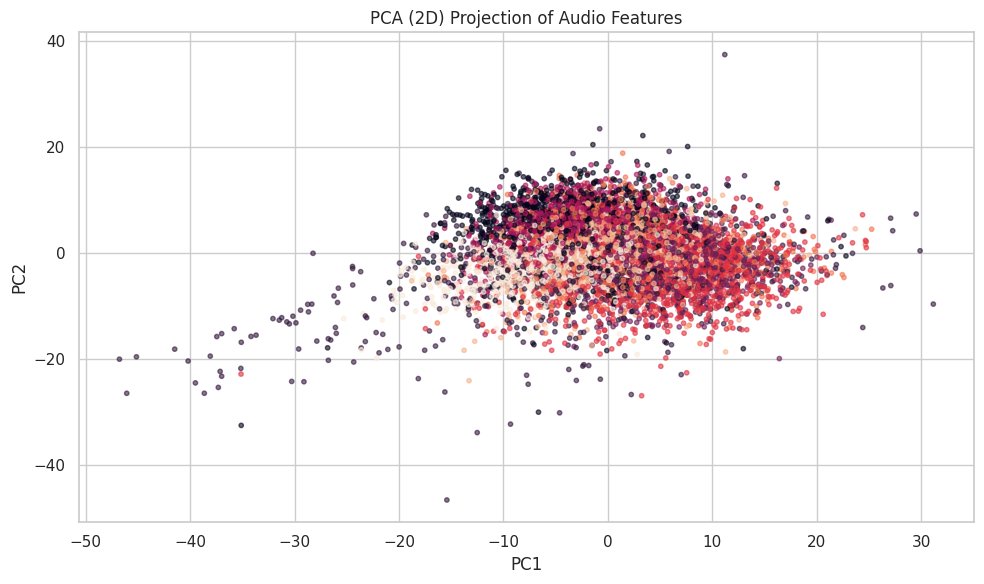

Explained variance ratio (PC1, PC2): [0.11810943 0.07535387]
Cumulative explained variance: 0.1934633020471755


,encoded,genre_top
0,0,Electronic
1,1,Experimental
2,2,Folk
3,3,Hip-Hop
4,4,Instrumental
5,5,International
6,6,Pop
7,7,Rock


In [28]:
# ==========================================
# 5.2.3 PCA 2D visualization (EDA only)
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Encode labels to integers for plotting
le = LabelEncoder()
y_enc = le.fit_transform(y.values)

pca_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2, random_state=RANDOM_STATE)),
])

X_2d = pca_pipe.fit_transform(X_df.values)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_enc, s=10, alpha=0.6)
plt.title("PCA (2D) Projection of Audio Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Optional: show explained variance ratio
pca_model = pca_pipe.named_steps["pca"]
print("Explained variance ratio (PC1, PC2):", pca_model.explained_variance_ratio_)
print("Cumulative explained variance:", pca_model.explained_variance_ratio_.sum())

# Provide mapping from color code to genre label (table)
label_map = pd.DataFrame({"encoded": range(len(le.classes_)), "genre_top": le.classes_})
display(label_map)


### 5.3 Train/Validation/Test Splits

We create reproducible train/validation/test splits for model evaluation.

**Strategy**
- Prefer the **official FMA split** if the metadata provides a complete split assignment for all selected tracks.
- Otherwise, fall back to a **stratified random split** (default: 60/20/20) using `RANDOM_STATE`.

Important: Splitting is performed on the final aligned dataset (`X_df`, `y`) to ensure indices match and to avoid accidental leakage from mismatched rows.


In [29]:
# ==========================================
# 5.3.1 Build train/val/test split indices
# ==========================================

from sklearn.model_selection import train_test_split

# --- Preconditions ---
if X_df is None or y is None:
    raise RuntimeError("X_df/y not found. Run Section 5.1 before Section 5.3.")

y = pd.Series(y, index=X_df.index, name="genre_top")
track_ids = X_df.index

# --- User-tunable settings (kept local to splitting) ---
PREFER_OFFICIAL_SPLIT = True
TRAIN_FRAC = 0.60
VAL_FRAC = 0.20
TEST_FRAC = 0.20

if not np.isclose(TRAIN_FRAC + VAL_FRAC + TEST_FRAC, 1.0):
    raise ValueError("TRAIN_FRAC + VAL_FRAC + TEST_FRAC must sum to 1.0")

# --- Helper: detect official split availability ---
split_col = ("set", "split")
use_official = False

if PREFER_OFFICIAL_SPLIT and split_col in tracks_df.columns:
    # Restrict to the track IDs actually in our final dataset
    split_series = tracks_df.loc[track_ids, split_col].astype(str).str.lower()

    # Common FMA labels are typically: training / validation / test
    valid_labels = {"training", "validation", "test"}
    observed = set(split_series.unique())

    # Check if all selected track_ids have one of the expected split labels
    all_valid = split_series.isin(valid_labels).all()
    has_all_splits = valid_labels.issubset(observed)

    if all_valid and has_all_splits:
        use_official = True

# --- Create split indices ---
if use_official:
    split_series = tracks_df.loc[track_ids, split_col].astype(str).str.lower()

    idx_train = split_series[split_series == "training"].index
    idx_val   = split_series[split_series == "validation"].index
    idx_test  = split_series[split_series == "test"].index

    split_strategy = "official"
    print("✅ Using OFFICIAL FMA split from tracks.csv")
else:
    # Stratified random split: (train) + (temp) then temp -> (val, test)
    idx_all = track_ids

    idx_train, idx_temp, y_train_tmp, y_temp = train_test_split(
        idx_all,
        y.loc[idx_all],
        test_size=(1.0 - TRAIN_FRAC),
        random_state=RANDOM_STATE,
        stratify=y.loc[idx_all],
    )

    # temp is VAL+TEST; split it proportionally
    val_ratio_within_temp = VAL_FRAC / (VAL_FRAC + TEST_FRAC)

    idx_val, idx_test = train_test_split(
        idx_temp,
        test_size=(1.0 - val_ratio_within_temp),
        random_state=RANDOM_STATE,
        stratify=y.loc[idx_temp],
    )

    split_strategy = "random_stratified"
    print("✅ Using STRATIFIED RANDOM split (60/20/20)")

# --- Materialize split datasets ---
X_train, y_train = X_df.loc[idx_train], y.loc[idx_train]
X_val,   y_val   = X_df.loc[idx_val],   y.loc[idx_val]
X_test,  y_test  = X_df.loc[idx_test],  y.loc[idx_test]

print("\n=== Split sizes ===")
print(f"Strategy : {split_strategy}")
print(f"Train    : {X_train.shape[0]:,}")
print(f"Val      : {X_val.shape[0]:,}")
print(f"Test     : {X_test.shape[0]:,}")

# Basic sanity checks
assert X_train.index.is_unique and X_val.index.is_unique and X_test.index.is_unique
assert set(X_train.index).isdisjoint(set(X_val.index))
assert set(X_train.index).isdisjoint(set(X_test.index))
assert set(X_val.index).isdisjoint(set(X_test.index))


✅ Using OFFICIAL FMA split from tracks.csv

=== Split sizes ===
Strategy : official
Train    : 6,400
Val      : 800
Test     : 800


#### 5.3.2 Split Diagnostics (Label Balance & Reproducibility)

We verify that each split preserves a similar class distribution (stratification / official design).  
We report:
- class counts per split
- class proportions per split

Optionally, we save split indices to disk to ensure exact reproducibility across runs.


=== Class counts per split ===


,train,val,test
genre_top,,,
Electronic,800,100,100
Experimental,800,100,100
Folk,800,100,100
Hip-Hop,800,100,100
Instrumental,800,100,100
International,800,100,100
Pop,800,100,100
Rock,800,100,100



=== Class proportions per split ===


,train,val,test
genre_top,,,
Electronic,12.5,12.5,12.5
Experimental,12.5,12.5,12.5
Folk,12.5,12.5,12.5
Hip-Hop,12.5,12.5,12.5
Instrumental,12.5,12.5,12.5
International,12.5,12.5,12.5
Pop,12.5,12.5,12.5
Rock,12.5,12.5,12.5


<Figure size 1000x600 with 0 Axes>

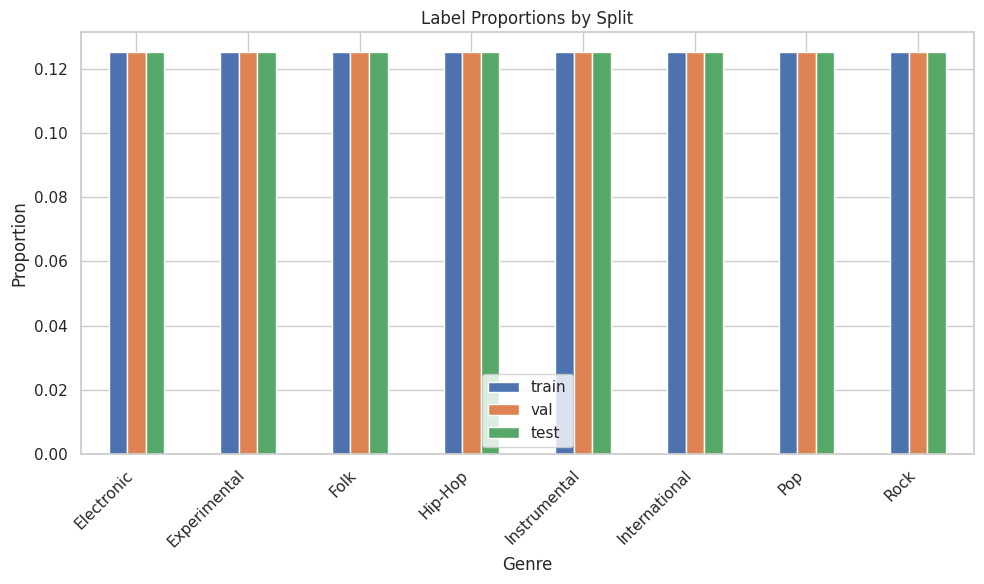


✅ Saved split indices to: /users/PAS2038/ji693/BigDataCourse/final_project/cache/split_small.json


In [30]:
# ==========================================
# 5.3.2 Diagnostics + optional saving of split indices
# ==========================================

def _split_label_table(y_train, y_val, y_test) -> tuple[pd.DataFrame, pd.DataFrame]:
    counts = pd.DataFrame({
        "train": y_train.value_counts(),
        "val":   y_val.value_counts(),
        "test":  y_test.value_counts(),
    }).fillna(0).astype(int)

    props = counts.div(counts.sum(axis=0), axis=1)
    return counts.sort_index(), props.sort_index()

counts, props = _split_label_table(y_train, y_val, y_test)

print("=== Class counts per split ===")
display(counts)

print("\n=== Class proportions per split ===")
display((props * 100).round(2))

# Simple visualization: proportions per split (stacked bar)
plt.figure()
props.plot(kind="bar", stacked=False)
plt.title("Label Proportions by Split")
plt.xlabel("Genre")
plt.ylabel("Proportion")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Optional: persist split indices for exact reproducibility
SAVE_SPLIT_INDICES = True

if SAVE_SPLIT_INDICES:
    split_payload = {
        "strategy": split_strategy,
        "random_state": int(RANDOM_STATE),
        "subset": str(SUBSET),
        "idx_train": [int(i) for i in idx_train],
        "idx_val":   [int(i) for i in idx_val],
        "idx_test":  [int(i) for i in idx_test],
    }
    split_path.parent.mkdir(parents=True, exist_ok=True)
    split_path.write_text(json.dumps(split_payload, indent=2))
    print(f"\n✅ Saved split indices to: {split_path}")
else:
    print("\nℹ️  SAVE_SPLIT_INDICES=False, not saving split indices.")


---

## 6. Methods (Modeling and Evaluation)

This section describes the modeling protocol used to evaluate baseline classifiers on the prepared FMA dataset.

**Data usage**
- We use the `train` and `validation` splits for model selection via cross-validation.
- We fit the selected model on **train+val** and evaluate once on the held-out **test** set.

**Leakage-safe pipelines**
All preprocessing steps (imputation and scaling) are implemented inside scikit-learn `Pipeline`s, ensuring they are fit **only on training folds** during cross-validation.

**Metrics**
- Primary metric: **macro-F1** (more robust for multi-class performance comparison)
- Secondary metrics: accuracy and weighted-F1


### 6.1 Utilities: Train+Val Merge and Evaluation Setup

We merge the training and validation sets for cross-validation-based model selection.
This cell also defines:
- Stratified K-Fold cross-validation (`cv`)
- the scoring dictionary (`scoring`) with macro-F1 as the primary metric


In [31]:
# ==========================================
# 6.1 Utilities: Train/Val merge + CV + scoring
# ==========================================

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

# Preconditions (from Section 5.3)
required = ["X_train", "X_val", "X_test", "y_train", "y_val", "y_test", "RANDOM_STATE"]
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables from Section 5.3: {missing}")

# Combine train + val for CV/model selection
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

print("X_trainval:", X_trainval.shape, "| y_trainval:", y_trainval.shape)
print("X_test    :", X_test.shape,     "| y_test    :", y_test.shape)

# Stratified CV (course-standard)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Metrics: macro-F1 is the primary selection metric
scoring = {
    "acc": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}


X_trainval: (7200, 518) | y_trainval: (7200,)
X_test    : (800, 518) | y_test    : (800,)


### 6.2 Baseline Models (Leakage-Safe Pipelines)

We define a small set of baseline classifiers:

- **Dummy (most frequent)**: sanity-check baseline (no learning)
- **Logistic Regression**: linear multiclass baseline with scaling
- **Random Forest**: nonlinear baseline (tree ensemble)

All preprocessing (imputation and scaling) is performed inside pipelines to avoid data leakage.


In [32]:
# ==========================================
# 6.2 Baseline Models (Leakage-safe Pipelines)
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1) Dummy baseline (most frequent class)
dummy_pipe = Pipeline(steps=[
    ("model", DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE))
])

# 2) Logistic Regression baseline (multiclass)
lr_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE,
        # keep defaults for solver/multiclass to maximize compatibility across sklearn versions
    )),
])

# 3) Random Forest baseline (no scaling needed)
rf_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

models = {
    "DummyMostFrequent": dummy_pipe,
    "LogReg": lr_pipe,
    "RandomForest": rf_pipe,
}

print("✅ Defined baseline pipelines:", list(models.keys()))


✅ Defined baseline pipelines: ['DummyMostFrequent', 'LogReg', 'RandomForest']


### 6.3 Cross-Validation Results (mean ± std)

We evaluate each baseline using 5-fold stratified cross-validation on the combined train+val set.
Models are ranked primarily by **macro-F1 mean** (higher is better).


In [33]:
# ==========================================
# 6.3 Cross-Validation (mean ± std)
# ==========================================

results = []

for name, pipe in models.items():
    cv_out = cross_validate(
        pipe,
        X_trainval,
        y_trainval,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    row = {
        "model": name,
        "acc_mean": float(np.mean(cv_out["test_acc"])),
        "acc_std":  float(np.std(cv_out["test_acc"], ddof=1)),
        "f1_macro_mean": float(np.mean(cv_out["test_f1_macro"])),
        "f1_macro_std":  float(np.std(cv_out["test_f1_macro"], ddof=1)),
        "f1_weighted_mean": float(np.mean(cv_out["test_f1_weighted"])),
        "f1_weighted_std":  float(np.std(cv_out["test_f1_weighted"], ddof=1)),
    }
    results.append(row)

cv_results_df = (
    pd.DataFrame(results)
      .sort_values(["f1_macro_mean", "acc_mean"], ascending=False)
      .reset_index(drop=True)
)

display(cv_results_df.round(4))


,model,acc_mean,acc_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,RandomForest,0.5753,0.0090,0.5668,0.0088,0.5668,0.0088
1,LogReg,0.5449,0.0084,0.5430,0.0083,0.5430,0.0083
2,DummyMostFrequent,0.1250,0.0000,0.0278,0.0000,0.0278,0.0000


### 6.4 Final Fit and Test Evaluation

We select the best baseline by CV macro-F1, fit it once on the combined train+val data,
and report performance on the held-out test set (classification report + confusion matrix).


✅ Best model by CV macro-F1: RandomForest
{'model': 'RandomForest', 'acc_mean': 0.5752777777777778, 'acc_std': 0.00898225703028058, 'f1_macro_mean': 0.5668255308647161, 'f1_macro_std': 0.008833232927607184, 'f1_weighted_mean': 0.5668255308647161, 'f1_weighted_std': 0.00883323292760721}

=== Test Classification Report ===
               precision    recall  f1-score   support

   Electronic     0.5169    0.6100    0.5596       100
 Experimental     0.3867    0.2900    0.3314       100
         Folk     0.2212    0.2300    0.2255       100
      Hip-Hop     0.5727    0.6300    0.6000       100
 Instrumental     0.4602    0.5200    0.4883       100
International     0.5155    0.5000    0.5076       100
          Pop     0.5000    0.3800    0.4318       100
         Rock     0.6168    0.6600    0.6377       100

     accuracy                         0.4775       800
    macro avg     0.4737    0.4775    0.4727       800
 weighted avg     0.4737    0.4775    0.4727       800


=== Test Conf

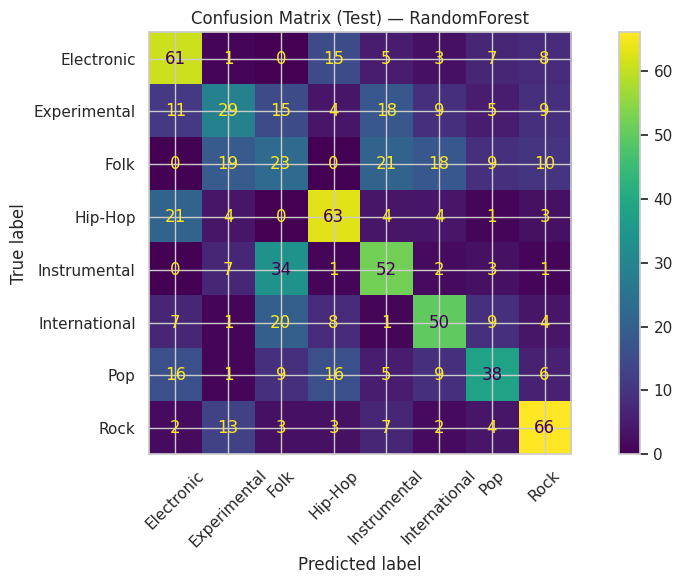

In [34]:
# ==========================================
# 6.4 Final Fit on Train+Val, Evaluate on Test
# ==========================================

from sklearn.metrics import classification_report, ConfusionMatrixDisplay

best_name = cv_results_df.iloc[0]["model"]
best_model = models[best_name]

print("✅ Best model by CV macro-F1:", best_name)
print(cv_results_df.iloc[0].to_dict())

best_model.fit(X_trainval, y_trainval)
y_pred_test = best_model.predict(X_test)

print("\n=== Test Classification Report ===")
print(classification_report(y_test, y_pred_test, digits=4))

print("\n=== Test Confusion Matrix ===")
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test, xticks_rotation=45, normalize=None
)
plt.title(f"Confusion Matrix (Test) — {best_name}")
plt.tight_layout()
plt.show()


### 6.5 Bias–Variance Discussion (Course Connection)

We use the cross-validation results as empirical evidence of the bias–variance tradeoff:

- **Higher variance** often appears as **larger fold-to-fold standard deviation** (performance is sensitive to the training split).
- **Higher bias** often appears as **lower mean performance** (the model underfits the true decision boundary).

In the next cell, we summarize mean ± std across folds for each model to support this discussion quantitatively.


In [35]:
# ==========================================
# 6.5 Bias–Variance: quantitative summary from CV
# ==========================================

if "cv_results_df" not in globals():
    raise RuntimeError("cv_results_df not found. Run Section 6.3 before 6.5.")

summary = cv_results_df.copy()
summary["macroF1_mean±std"] = summary.apply(
    lambda r: f"{r['f1_macro_mean']:.4f} ± {r['f1_macro_std']:.4f}", axis=1
)
summary["acc_mean±std"] = summary.apply(
    lambda r: f"{r['acc_mean']:.4f} ± {r['acc_std']:.4f}", axis=1
)

display(summary[["model", "macroF1_mean±std", "acc_mean±std"]])

# Simple textual cues (no hard-coded claims)
best = summary.iloc[0]
most_variable = summary.sort_values("f1_macro_std", ascending=False).iloc[0]

print("\n=== Interpretation cues ===")
print(f"- Best (by macro-F1 mean): {best['model']} -> {best['macroF1_mean±std']}")
print(f"- Most variable (largest macro-F1 std): {most_variable['model']} -> {most_variable['macroF1_mean±std']}")
print("Note: Larger std suggests higher variance across folds; lower mean suggests higher bias.")


,model,macroF1_mean±std,acc_mean±std
0,RandomForest,0.5668 ± 0.0088,0.5753 ± 0.0090
1,LogReg,0.5430 ± 0.0083,0.5449 ± 0.0084
2,DummyMostFrequent,0.0278 ± 0.0000,0.1250 ± 0.0000



=== Interpretation cues ===
- Best (by macro-F1 mean): RandomForest -> 0.5668 ± 0.0088
- Most variable (largest macro-F1 std): RandomForest -> 0.5668 ± 0.0088
Note: Larger std suggests higher variance across folds; lower mean suggests higher bias.


---

## 7. Results

This section reports model performance using two stages:

1) **Cross-validation on train+val** (5-fold stratified CV) to compare baseline models.  
   We rank models primarily by **macro-F1 (mean ± std)**, with accuracy and weighted-F1 as secondary references.

2) **Final held-out test evaluation** using the single best baseline selected by CV.  
   The chosen model is fit once on **train+val** and evaluated once on **test** (classification report + confusion matrix).

(Experimental setup details are described in Section 6; this section focuses on outcomes and interpretation.)


### 7.1 Cross-Validation Performance (Mean ± Std)

We compare baseline models using 5-fold stratified cross-validation on the combined **train+val** set.
The table below summarizes each model’s performance as mean ± standard deviation across folds.

Selection rule:
- **Primary:** macro-F1 mean (higher is better)
- **Secondary:** accuracy mean (tie-breaker)


In [36]:
# ==================================
# 7.1 CV Results Summary
# ==================================

import numpy as np
import pandas as pd

if "cv_results_df" not in globals():
    raise RuntimeError("cv_results_df not found. Run Section 6.3 before Section 7.1.")

display(cv_results_df.round(4))

best = cv_results_df.iloc[0]
print("\n=== Best model by CV macro-F1 ===")
print(f"Model       : {best['model']}")
print(f"macro-F1    : {best['f1_macro_mean']:.4f} ± {best['f1_macro_std']:.4f}")
print(f"accuracy    : {best['acc_mean']:.4f} ± {best['acc_std']:.4f}")
print(f"weighted-F1 : {best['f1_weighted_mean']:.4f} ± {best['f1_weighted_std']:.4f}")


,model,acc_mean,acc_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,RandomForest,0.5753,0.0090,0.5668,0.0088,0.5668,0.0088
1,LogReg,0.5449,0.0084,0.5430,0.0083,0.5430,0.0083
2,DummyMostFrequent,0.1250,0.0000,0.0278,0.0000,0.0278,0.0000



=== Best model by CV macro-F1 ===
Model       : RandomForest
macro-F1    : 0.5668 ± 0.0088
accuracy    : 0.5753 ± 0.0090
weighted-F1 : 0.5668 ± 0.0088


### 7.2 Final Held-out Test Evaluation

After selecting the best baseline by CV macro-F1, we fit it once on **train+val** and evaluate once on the **test** set.

We report:
- test accuracy / macro-F1 / weighted-F1
- classification report (per-class precision/recall/F1)
- confusion matrix (raw counts and row-normalized)


=== Best baseline: RandomForest ===
Test accuracy    : 0.4775
Test macro-F1    : 0.4727
Test weighted-F1 : 0.4727

=== Classification Report (Test) ===
               precision    recall  f1-score   support

   Electronic     0.5169    0.6100    0.5596       100
 Experimental     0.3867    0.2900    0.3314       100
         Folk     0.2212    0.2300    0.2255       100
      Hip-Hop     0.5727    0.6300    0.6000       100
 Instrumental     0.4602    0.5200    0.4883       100
International     0.5155    0.5000    0.5076       100
          Pop     0.5000    0.3800    0.4318       100
         Rock     0.6168    0.6600    0.6377       100

     accuracy                         0.4775       800
    macro avg     0.4737    0.4775    0.4727       800
 weighted avg     0.4737    0.4775    0.4727       800



<Figure size 1000x600 with 0 Axes>

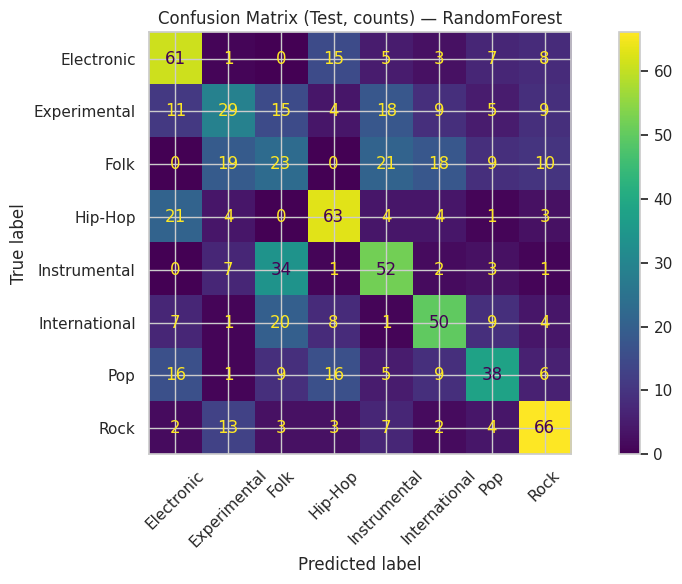

<Figure size 1000x600 with 0 Axes>

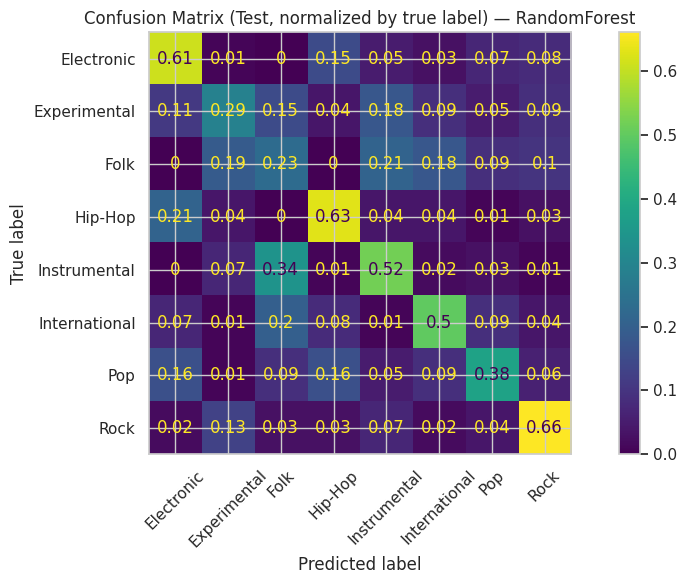

In [37]:
# ==================================
# 7.2 Test Evaluation
# ==================================

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Preconditions
needed = ["X_trainval", "y_trainval", "X_test", "y_test", "models", "cv_results_df"]
missing = [k for k in needed if k not in globals()]
if missing:
    raise RuntimeError(f"Missing variables required for test evaluation: {missing}")

# Determine best model (by CV)
best_name = cv_results_df.iloc[0]["model"]
best_model = models[best_name]

# Predict on test (recompute if needed)
if "y_pred_test" not in globals():
    best_model.fit(X_trainval, y_trainval)
    y_pred_test = best_model.predict(X_test)

# Scalar metrics
test_acc = accuracy_score(y_test, y_pred_test)
test_f1_macro = f1_score(y_test, y_pred_test, average="macro")
test_f1_weighted = f1_score(y_test, y_pred_test, average="weighted")

print(f"=== Best baseline: {best_name} ===")
print(f"Test accuracy    : {test_acc:.4f}")
print(f"Test macro-F1    : {test_f1_macro:.4f}")
print(f"Test weighted-F1 : {test_f1_weighted:.4f}")

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_pred_test, digits=4))

# Confusion matrix: raw counts
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, xticks_rotation=45, normalize=None)
plt.title(f"Confusion Matrix (Test, counts) — {best_name}")
plt.tight_layout()
plt.show()

# Confusion matrix: normalized by true label (rows)
plt.figure()
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, xticks_rotation=45, normalize="true")
plt.title(f"Confusion Matrix (Test, normalized by true label) — {best_name}")
plt.tight_layout()
plt.show()


### 7.3 Key Observations (What the Results Suggest)

In this section we summarize what the results imply:

- **Which baseline works best** under macro-F1 and how large the margin is relative to the next-best baseline.
- **Where the model struggles** by identifying the most common confusions (true genre → predicted genre).
- **Why macro-F1 matters**: if some genres are harder, macro-F1 captures class-wise performance more fairly than accuracy alone.

The next cell auto-generates a short results paragraph and lists the top confusions from the test confusion matrix.


In [38]:
# ==================================
# 7.3 Auto Results Paragraph + Top Confusions
# ==================================

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# Preconditions
if "cv_results_df" not in globals():
    raise RuntimeError("cv_results_df not found. Run Section 6.3 before Section 7.3.")
if "y_test" not in globals() or "y_pred_test" not in globals():
    raise RuntimeError("y_test / y_pred_test not found. Run Section 7.2 before Section 7.3.")

best = cv_results_df.iloc[0]
second = cv_results_df.iloc[1] if len(cv_results_df) > 1 else None

# --- Auto results paragraph (copy-ready) ---
paragraph = (
    f"Using 5-fold stratified cross-validation on the combined train+val set, "
    f"the best-performing baseline was {best['model']} with macro-F1 "
    f"{best['f1_macro_mean']:.3f} ± {best['f1_macro_std']:.3f} "
    f"and accuracy {best['acc_mean']:.3f} ± {best['acc_std']:.3f}. "
)
if second is not None:
    paragraph += (
        f"The next-best baseline was {second['model']} with macro-F1 "
        f"{second['f1_macro_mean']:.3f} ± {second['f1_macro_std']:.3f}. "
    )
paragraph += (
    "On the held-out test set, we further analyze class-wise behavior via the confusion matrix "
    "to identify which genres are most frequently confused."
)

print("=== Copy-ready Results Paragraph ===")
print(paragraph)

# --- Top confusions from test confusion matrix ---
labels = sorted(pd.unique(pd.Series(y_test)))
cm = confusion_matrix(y_test, y_pred_test, labels=labels)

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

K = 10
flat_order = np.argsort(cm_no_diag.ravel())[::-1]
rows, cols = np.unravel_index(flat_order, cm_no_diag.shape)

top = []
for r, c in zip(rows, cols):
    if cm_no_diag[r, c] <= 0:
        break
    top.append((labels[r], labels[c], int(cm_no_diag[r, c])))
    if len(top) >= K:
        break

top_df = pd.DataFrame(top, columns=["true_label", "pred_label", "count"])

print("\n=== Top Confusions (true → predicted) ===")
if len(top_df) == 0:
    print("No confusions found (perfect diagonal), which is unlikely but possible on tiny test sets.")
else:
    display(top_df)


=== Copy-ready Results Paragraph ===
Using 5-fold stratified cross-validation on the combined train+val set, the best-performing baseline was RandomForest with macro-F1 0.567 ± 0.009 and accuracy 0.575 ± 0.009. The next-best baseline was LogReg with macro-F1 0.543 ± 0.008. On the held-out test set, we further analyze class-wise behavior via the confusion matrix to identify which genres are most frequently confused.

=== Top Confusions (true → predicted) ===


,true_label,pred_label,count
0,Instrumental,Folk,34
1,Hip-Hop,Electronic,21
2,Folk,Instrumental,21
3,International,Folk,20
4,Folk,Experimental,19
5,Folk,International,18
6,Experimental,Instrumental,18
7,Pop,Hip-Hop,16
8,Pop,Electronic,16
9,Experimental,Folk,15


### 7.4 Notes for the Next Section

Section 7 focused on reporting **what happened** (CV ranking, test performance, and error patterns).
In Section 8 (Discussion), we will interpret **why** these patterns appear and what they imply about:
- feature limitations (statistical descriptors vs temporal structure),
- model capacity (linear vs nonlinear baselines),
- and possible improvements (e.g., richer representations or stronger models).


In [21]:
# ==================================
# 7.4 Auto Results Paragraph (copy)
# ==================================

best = cv_results_df.iloc[0]
second = cv_results_df.iloc[1] if len(cv_results_df) > 1 else None

paragraph = (
    f"Using stratified cross-validation on the training set (train+val), "
    f"the best-performing baseline was {best['model']} with macro-F1 "
    f"{best['f1_macro_mean']:.3f} ± {best['f1_macro_std']:.3f} "
    f"and accuracy {best['acc_mean']:.3f} ± {best['acc_std']:.3f}. "
)

if second is not None:
    paragraph += (
        f"The next-best model was {second['model']} (macro-F1 "
        f"{second['f1_macro_mean']:.3f} ± {second['f1_macro_std']:.3f}). "
    )

paragraph += (
    "We then retrained the selected model on the full train+val split and evaluated once on the held-out test set. "
    "The test classification report and confusion matrix reveal class-wise differences in performance, "
    "highlighting that some genres are consistently harder to distinguish than others."
)

print(paragraph)


Using stratified cross-validation on the training set (train+val), the best-performing baseline was RandomForest with macro-F1 0.567 ± 0.008 and accuracy 0.575 ± 0.008. The next-best model was LogReg (macro-F1 0.552 ± 0.006). We then retrained the selected model on the full train+val split and evaluated once on the held-out test set. The test classification report and confusion matrix reveal class-wise differences in performance, highlighting that some genres are consistently harder to distinguish than others.


In [22]:
# ==================================
# 7.5 Top Confusions (optional)
# ==================================
cm = confusion_matrix(y_test, y_pred_test, labels=sorted(y_all.unique()))
labels = sorted(y_all.unique())

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

# find top K confusions
K = 10
flat_idx = np.dstack(np.unravel_index(np.argsort(cm_no_diag.ravel())[::-1], cm_no_diag.shape))[0]
top = []
for i, j in flat_idx[:K]:
    if cm_no_diag[i, j] > 0:
        top.append((labels[i], labels[j], int(cm_no_diag[i, j])))

top_df = pd.DataFrame(top, columns=["true_label", "pred_label", "count"])
print("Top confusions (true → predicted):")
display(top_df)


Top confusions (true → predicted):


,true_label,pred_label,count
0,Instrumental,Folk,34
1,Hip-Hop,Electronic,21
2,Folk,Instrumental,21
3,International,Folk,20
4,Folk,Experimental,19
5,Folk,International,18
6,Experimental,Instrumental,18
7,Pop,Hip-Hop,16
8,Pop,Electronic,16
9,Experimental,Folk,15


*Note:* The experimental protocol (splits, pipelines, cross-validation, and metric definitions) is described in **Section 6** to avoid repetition.


---

## 8. Discussion

### 8.1 Summary of findings
Using the **official FMA split** (train=6400, val=800, test=800; each class has 100 tracks in test), the baseline comparison via 5-fold stratified CV on train+val shows that **RandomForest allowing nonlinear decision boundaries performs best** (CV macro-F1 ≈ 0.5668 ± 0.0088; CV accuracy ≈ 0.5753 ± 0.0090), followed by Logistic Regression (CV macro-F1 ≈ 0.5430 ± 0.0083). The DummyMostFrequent baseline reaches accuracy 0.125 (chance-level for 8 balanced classes), confirming that the task is non-trivial.
On the held-out **test** set, the selected RandomForest achieves **accuracy ≈ 0.4775** and **macro-F1 ≈ 0.4727**.

### 8.2 Why RandomForest outperformed Logistic Regression
The pre-computed audio feature set contains many statistical descriptors (e.g., summary statistics of spectral and timbral components). The relationship between these descriptors and genre labels is likely **nonlinear** and involves **feature interactions**. RandomForest can capture nonlinear boundaries and interaction effects by combining multiple decision trees, which plausibly explains its CV advantage over Logistic Regression, whose decision boundary is linear in the (scaled) feature space.  
Notably, the fold-to-fold standard deviations for both models are relatively small (~0.008–0.009 in macro-F1), suggesting the performance ranking is fairly stable under resampling of train+val, i.e., results are not dominated by high variance across folds.

### 8.3 Generalization gap: CV vs test
Although CV on train+val indicates macro-F1 around **0.567**, the test macro-F1 is around **0.473**, indicating a noticeable generalization gap. This gap may reflect:
- limitations of the statistical feature representation (insufficient capture of temporal/structural cues that distinguish genres),
- model capacity limits (the baseline RF is still relatively simple compared with modern audio models),
- and possible distribution differences between the official test partition and the cross-validation folds inside train+val.

This motivates exploring richer representations and/or stronger models rather than relying only on baseline classifiers.

### 8.4 Error analysis (confusion patterns)
Class-wise behavior on test shows that some genres are recognized well while others are substantially harder:
- Stronger classes (higher f1): **Rock (~0.638), Hip-Hop (~0.600), Electronic (~0.560)**
- Harder classes (lower f1): **Folk (~0.226), Experimental (~0.331), Pop (~0.432)**

The confusion matrix reveals consistent, interpretable confusions (true → predicted, counts):
- **Instrumental → Folk (34)** and **Folk → Instrumental (21)**: both can share acoustic timbre and low percussive/beat-driven signatures; statistical descriptors may not capture the musical structure that differentiates them.
- **International → Folk (20)** and **Folk → International (18)**: “International” is broad; timbral features alone may group culturally diverse recordings into acoustically similar clusters.
- **Hip-Hop → Electronic (21)** and **Pop → Hip-Hop/Electronic (16/16)**: production patterns (drums, bass, compression, synth textures) can overlap, leading to boundary ambiguity under feature summaries.
- **Experimental → Instrumental/Folk (18/15)**: experimental recordings can be heterogeneous and may not form a tight cluster in the chosen feature space.

Overall, many errors occur between genres that are acoustically adjacent or stylistically overlapping, suggesting that the current feature set does not fully disentangle those distinctions.

### 8.5 Metric interpretation (why macro-F1)
We rank models primarily by **macro-F1** because it evaluates per-class performance more evenly. In this project the dataset is balanced across the 8 genres (especially in the test set), which explains why **macro-F1 and weighted-F1 are nearly identical** in the reported results. Even in a balanced setting, macro-F1 remains a robust summary because it discourages optimizing only the easiest classes.

### 8.6 Limitations
1. **Feature representation**: `features.csv` consists of summary statistics and does not directly encode temporal evolution (rhythm patterns, long-range structure, section transitions), which are important for genre discrimination.
2. **Model strength**: only baseline models were evaluated (Dummy, LR, RF) with limited hyperparameter tuning.
3. **Genre ambiguity / label noise**: genre labels can be subjective; some tracks plausibly belong to multiple genres, limiting achievable performance.
4. **Evaluation protocol**: CV is performed within train+val while test is the official held-out set; differences between these partitions can contribute to the observed generalization gap.

### 8.7 Future work
- **Stronger classical models**: systematic hyperparameter search for RF/LR; try SVM or gradient-boosted trees (e.g., XGBoost/LightGBM) on the same features.
- **Richer audio representations**: learn features from mel-spectrograms using CNNs or sequence models (RNN/Transformer) to capture temporal structure.
- **Uncertainty and calibration (optional extension)**: analyze prediction confidence to identify “ambiguous” tracks; Bayesian/MC-dropout ideas could support uncertainty-aware evaluation.
- **Deeper error analysis**: inspect representative misclassified examples for the top confusion pairs to validate whether errors reflect true acoustic similarity or model/feature limitations.


## 9. Conclusion

In this project, we addressed **8-class music genre classification** on the FMA *small* subset using the provided pre-computed audio features. Following a leakage-safe workflow with scikit-learn pipelines (imputation and scaling inside cross-validation), we compared baseline classifiers via **5-fold stratified CV** on the combined train+val split and selected models primarily by **macro-F1**.

Across baselines, **RandomForest** achieved the best cross-validation performance (macro-F1 ≈ **0.5668 ± 0.0088**, accuracy ≈ **0.5753 ± 0.0090**), outperforming Logistic Regression, while the Dummy baseline confirmed chance-level performance for a balanced 8-class task. When trained on train+val and evaluated once on the held-out test set, the selected RandomForest reached **test accuracy ≈ 0.4775** and **test macro-F1 ≈ 0.4727**, with errors concentrated among acoustically similar or stylistically overlapping genres (e.g., Instrumental vs Folk and International vs Folk).

Overall, these results suggest that summary-statistic audio descriptors enable **moderate** genre discrimination, but they leave substantial ambiguity for closely related genres. Future work should explore **richer representations** (e.g., time–frequency inputs such as mel-spectrograms) and **stronger models / systematic tuning** to better capture temporal structure and reduce confusions observed in the test confusion matrix.
